In [1]:
## 1. Data cleaning and preparation

#In this notebook, I clean and standardize the raw price data collected in Notebook 01. 
#The goal is to ensure:
#- Consistent time series across all assets
#- Minimal missing data issues
#- A clean dataset ready for factor construction and backtesting

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
## 2. Set project paths and load the data
project_root = Path.cwd().parent
raw_data_path = project_root / "data" / "raw"
price_data = pd.read_csv(raw_data_path / "prices.csv", index_col=0)
price_data.index = pd.to_datetime(price_data.index)
price_data.head()

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304173,69.343719,135.558258,177.699997,59.450500,21.086662,24.637497,197.220001,168.498184,102.899277,...,20.107000,4.928266,91.602791,72.824966,236.562180,188.755325,193.090485,108.111916,28.855198,58.580421
2018-01-03,40.297161,70.428848,136.183853,181.039993,60.209999,21.317259,24.555096,199.789993,170.520294,103.766556,...,20.504999,5.252614,91.362274,72.736610,238.058411,192.217896,195.116028,109.188217,29.106909,59.730961
2018-01-04,40.484329,70.027191,137.796402,183.220001,60.479500,21.324375,24.876453,200.690002,169.196091,105.136429,...,20.563000,5.280302,91.812271,73.250755,239.061844,194.623993,195.962891,109.594200,29.133242,59.813622
2018-01-05,40.945259,71.246223,138.933090,185.339996,61.457001,21.450729,24.991814,201.419998,167.988129,106.535881,...,20.999001,5.325049,92.076096,73.298973,240.654938,197.959396,199.699692,112.218857,29.305925,59.765404
2018-01-08,40.793179,70.104713,140.043381,185.039993,62.343498,21.502064,24.818777,202.740005,168.641266,107.284882,...,21.205000,5.488214,91.548485,73.684570,241.095032,198.282120,196.233566,112.672028,29.739092,60.034073


In [4]:
## 3. Data validation
close_prices = price_data.copy()
print("Shape of the close price data:", close_prices.shape)
print("Start date:", close_prices.index.min())
print("End date:", close_prices.index.max())
print("Number of assest:", close_prices.shape[1])
print("Duplicate dates:", close_prices.index.duplicated().sum())
print("Duplicate tickers:", close_prices.columns.duplicated().sum())
print("Total missing values", close_prices.isna().sum().sum())

Shape of the close price data: (2080, 31)
Start date: 2018-01-02 00:00:00
End date: 2026-04-13 00:00:00
Number of assest: 31
Duplicate dates: 0
Duplicate tickers: 0
Total missing values 0


In [5]:
## 4. Check data type and sort
close_prices.info()
close_prices.sort_index()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2080 entries, 2018-01-02 to 2026-04-13
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2080 non-null   float64
 1   ABBV    2080 non-null   float64
 2   ACN     2080 non-null   float64
 3   ADBE    2080 non-null   float64
 4   AMZN    2080 non-null   float64
 5   AVGO    2080 non-null   float64
 6   BAC     2080 non-null   float64
 7   BRK-B   2080 non-null   float64
 8   COST    2080 non-null   float64
 9   CRM     2080 non-null   float64
 10  CVX     2080 non-null   float64
 11  GOOGL   2080 non-null   float64
 12  HD      2080 non-null   float64
 13  JPM     2080 non-null   float64
 14  KO      2080 non-null   float64
 15  LLY     2080 non-null   float64
 16  MA      2080 non-null   float64
 17  MCD     2080 non-null   float64
 18  META    2080 non-null   float64
 19  MRK     2080 non-null   float64
 20  MSFT    2080 non-null   float64
 21  NFLX    2080 non-nu

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304173,69.343719,135.558258,177.699997,59.450500,21.086662,24.637497,197.220001,168.498184,102.899277,...,20.107000,4.928266,91.602791,72.824966,236.562180,188.755325,193.090485,108.111916,28.855198,58.580421
2018-01-03,40.297161,70.428848,136.183853,181.039993,60.209999,21.317259,24.555096,199.789993,170.520294,103.766556,...,20.504999,5.252614,91.362274,72.736610,238.058411,192.217896,195.116028,109.188217,29.106909,59.730961
2018-01-04,40.484329,70.027191,137.796402,183.220001,60.479500,21.324375,24.876453,200.690002,169.196091,105.136429,...,20.563000,5.280302,91.812271,73.250755,239.061844,194.623993,195.962891,109.594200,29.133242,59.813622
2018-01-05,40.945259,71.246223,138.933090,185.339996,61.457001,21.450729,24.991814,201.419998,167.988129,106.535881,...,20.999001,5.325049,92.076096,73.298973,240.654938,197.959396,199.699692,112.218857,29.305925,59.765404
2018-01-08,40.793179,70.104713,140.043381,185.039993,62.343498,21.502064,24.818777,202.740005,168.641266,107.284882,...,21.205000,5.488214,91.548485,73.684570,241.095032,198.282120,196.233566,112.672028,29.739092,60.034073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-07,253.500000,206.369995,195.640900,240.139999,213.770004,333.970001,50.279999,478.079987,1013.210022,182.503571,...,98.820000,178.100006,153.210007,141.300003,659.219971,489.500000,307.730011,302.549988,122.489998,163.910004
2026-04-08,258.899994,211.589996,192.209991,239.309998,221.250000,350.630005,51.880001,479.750000,1030.270020,175.929993,...,99.389999,182.080002,154.800003,144.899994,676.010010,503.459991,305.980011,308.959991,127.260002,156.220001
2026-04-09,260.489990,212.399994,186.029999,229.940002,233.649994,354.910004,52.709999,485.200012,1032.030029,170.850006,...,102.050003,183.910004,157.490005,146.660004,679.909973,500.459991,306.910004,308.290009,129.130005,155.039993


In [6]:
## 5. Check for non-positive values
non_positive_counts = (close_prices<=0).sum().sort_values(ascending=False)
problem_assets = non_positive_counts[non_positive_counts>0]
print(f"Number of non-positive values is: {len(problem_assets)}")
print(problem_assets)

Number of non-positive values is: 0
Series([], dtype: int64)


In [7]:
close_prices.describe()

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
count,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,...,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000
mean,139.519640,119.373554,246.427753,402.467312,142.953030,91.271652,32.415804,312.118745,503.675696,205.765033,...,52.450971,49.037504,131.443285,123.694029,402.435381,444.075780,362.442946,220.148092,53.049888,75.988364
std,69.336510,51.010100,70.037918,121.186310,48.477933,95.437564,8.954660,106.729848,270.320046,56.059261,...,26.970709,58.708319,26.229409,29.979253,132.436639,132.595137,116.189613,66.252125,25.346521,30.398079
min,33.768078,48.014366,119.910599,177.699997,59.450500,14.411805,15.615927,162.130005,159.810211,102.524773,...,16.636999,3.150397,75.162003,57.956532,204.944839,188.755325,176.098114,107.498215,24.413349,23.985258
25%,66.863327,70.725643,177.463078,294.717491,95.053997,25.914727,25.166220,211.815006,274.473801,155.807484,...,33.319000,6.573699,111.123289,103.161760,276.211639,311.546021,249.897545,173.714260,36.256964,51.932674
50%,144.771744,120.454372,258.909088,384.960007,145.014999,48.328344,30.279983,288.539993,462.171631,204.108345,...,43.828501,18.616323,137.723312,129.128288,389.998611,491.429703,352.623596,208.924271,44.861843,68.442318
75%,188.390476,155.080944,301.273766,495.922501,176.632496,125.885025,38.354269,404.797508,716.141571,249.681988,...,62.333501,85.215158,153.858875,146.260620,493.606392,549.460388,471.138626,265.023766,58.375286,103.369740
max,285.922455,240.694290,390.997040,688.369995,254.000000,411.318512,56.928177,539.799988,1070.990356,364.156708,...,133.912994,207.017273,177.249710,173.840225,693.595764,659.204956,603.201172,371.152252,133.615784,171.470001


In [8]:
## 6. Summary stats
close_prices.describe().T.head()
daily_returns = close_prices.pct_change()
daily_returns.describe().T[["mean", "std", "min", "max"]].head()

,mean,std,min,max
AAPL,0.001081,0.019275,-0.128647,0.153289
ABBV,0.000669,0.016851,-0.162524,0.137673
ACN,0.000324,0.017708,-0.095881,0.128573
ADBE,0.000405,0.022705,-0.167932,0.177193
AMZN,0.000905,0.021642,-0.140494,0.135359


In [9]:
## 7. Check for extreme return
extreme_moves = (daily_returns.abs() > 0.2).sum().sort_values(ascending=False)
print(extreme_moves[extreme_moves > 0])

META    4
CVX     2
NFLX    2
UNH     1
AVGO    1
NVDA    1
CRM     1
dtype: int64


In [10]:
#Several assets (e.g., META, CVX, NFLX) exhibit daily returns exceeding 20%. 
#These extreme moves may correspond to earnings announcements, corporate actions such as stock splits, or potential data inconsistencies. 
#Further inspection of individual cases is required to distinguish between real market events and data anomalies.

In [11]:
## 8. Inspect META
meta_returns = daily_returns["META"]
meta_extreme = meta_returns[meta_returns.abs() > 0.2]
print(meta_extreme)

Date
2022-02-03   -0.263901
2022-10-27   -0.245571
2023-02-02    0.232824
2024-02-02    0.203177
Name: META, dtype: float64


In [12]:
close_prices.loc[meta_extreme.index, "META"]

Date
2022-02-03    235.908691
2022-10-27     97.177414
2023-02-02    187.300171
2024-02-02    471.291534
Name: META, dtype: float64

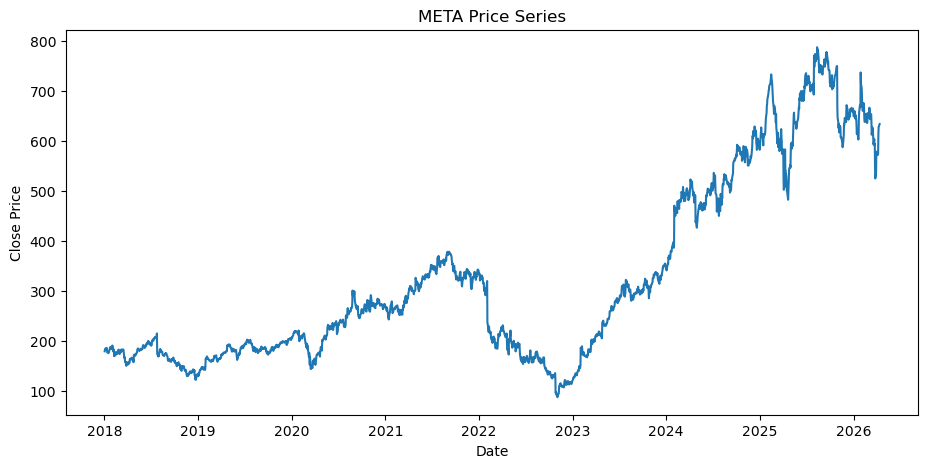

In [13]:
plt.figure(figsize=(11,5))
sns.lineplot(x=close_prices.index, y=close_prices["META"])
plt.title("META Price Series")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [14]:
#META exhibits several extreme daily returns (>20%), which upon inspection correspond to earnings announcements and major corporate developments. 
#These events represent genuine market reactions rather than data errors, so they are retained in the dataset.

In [15]:
## 9. Inspect NFLX
nflx_returns = daily_returns["NFLX"]
nflx_extreme = nflx_returns[nflx_returns.abs() > 0.2]
print(nflx_extreme)

Date
2022-01-21   -0.217905
2022-04-20   -0.351166
Name: NFLX, dtype: float64


In [16]:
close_prices.loc[nflx_extreme.index, "NFLX"]

Date
2022-01-21    39.750000
2022-04-20    22.618999
Name: NFLX, dtype: float64

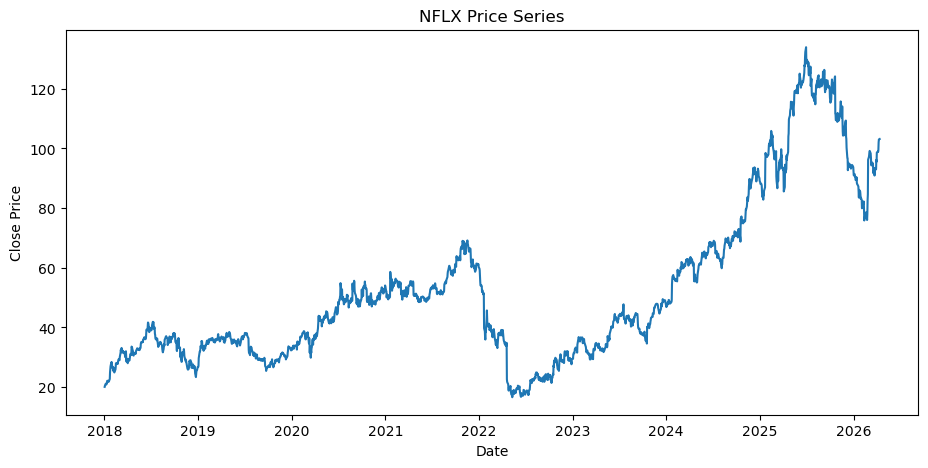

In [17]:
plt.figure(figsize=(11,5))
sns.lineplot(x=close_prices.index, y=close_prices["NFLX"])
plt.title("NFLX Price Series")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [18]:
## 10.Data Validation Conclusion:

#The dataset was validated for structural consistency, missing values, and financial plausibility. No non-positive prices or duplicate entries were detected.
#Extreme daily returns (>20%) were identified for several assets, including META and NFLX. Upon inspection, these events correspond to earnings announcements and major corporate developments rather than data errors.
#Therefore, the dataset is considered clean and suitable for downstream return modeling and portfolio analysis.

In [19]:
project_root = Path.cwd().parent
DATA_PROCESSED = project_root / "data" / "processed"
clean_path = DATA_PROCESSED / "notebook_02_data_prep"
clean_path.mkdir(parents=True, exist_ok=True)
close_prices.to_csv(clean_path / "clean_close_prices.csv")
daily_returns.to_csv(clean_path / "daily_returns.csv")